# Machine Learning Technologies - Lab 1
## Data Handling and Visualisation Fundamentals

**Objectives:**
1. Load and manipulate data with pandas
2. Visualise data with matplotlib
3. Work with images as numpy arrays
4. Get familiar with basic scikit-learn workflows

**Prerequisites:** Basic Python, numpy knowledge

---

## Part 1: NumPy Refresher

NumPy arrays are the foundation of scientific Python. Key things to remember:
- `.shape` tells you the dimensions
- `.dtype` tells you the data type
- All elements must be the same type (unlike pandas)

### Step 1.1: Import numpy

In [1]:
import numpy as np

### Step 1.2: Create arrays and inspect their properties

In [2]:
# 1D array — shape is (5,) meaning 5 elements, 1 dimension
a = np.array([1, 2, 3, 4, 5])
print("1D array:", a)
print("Shape:", a.shape, "| Dtype:", a.dtype)

1D array: [1 2 3 4 5]
Shape: (5,) | Dtype: int64


In [3]:
# 2D array — shape is (rows, columns)
b = np.array([[1, 2, 3, 4], [1, 2, 3, 4]])
print("2D array:\n", b)
print("Shape:", b.shape, "| Dtype:", b.dtype)

2D array:
 [[1 2 3 4]
 [1 2 3 4]]
Shape: (2, 4) | Dtype: int64


### Step 1.3: Useful array creation functions

In [4]:
# np.ones() creates an array filled with 1s
c = np.ones([3, 3])
print("Ones:\n", c)

# np.arange() creates a range (like Python's range but returns an array)
d = np.arange(1, 5)
print("\nArange:", d)

Ones:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

Arange: [1 2 3 4]


### Step 1.4: Student Task — create a 3×4 array with values 0–11

In [5]:
# np.arange creates the values, .reshape changes the shape
e = np.arange(12).reshape(3, 4)
print(e)
print("Shape:", e.shape)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Shape: (3, 4)


---
## Part 2: Working with Pandas

Pandas provides labelled, tabular data structures:
- **Series**: 1D labelled array (like a column)
- **DataFrame**: 2D labelled table (like a spreadsheet)

Unlike numpy, columns can have different data types.

### Step 2.1: Imports

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Widen the display so columns don't get cut off
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

### Step 2.2: Create a DataFrame from a dictionary

In [7]:
# Each key becomes a column name, each value list becomes the column data
data = {
    "name": ["Alice", "Bob", "Charlie", "Diana"],
    "age": [21, 23, 22, 24],
    "grade": [68, 75, 82, 90]
}

df = pd.DataFrame(data)
df

,name,age,grade
0,Alice,21,68
1,Bob,23,75
2,Charlie,22,82
3,Diana,24,90


### Step 2.3: Inspect the DataFrame

In [8]:
# .info() shows column names, non-null counts, and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    4 non-null      str  
 1   age     4 non-null      int64
 2   grade   4 non-null      int64
dtypes: int64(2), str(1)
memory usage: 228.0 bytes


### Step 2.4: Select columns

In [9]:
# Single column → returns a Series
print(df["name"])

# .values converts a Series to a numpy array
print("\nAs numpy array:")
print(df["name"].values)

0      Alice
1        Bob
2    Charlie
3      Diana
Name: name, dtype: str

As numpy array:
<StringArray>
['Alice', 'Bob', 'Charlie', 'Diana']
Length: 4, dtype: str


### Step 2.5: Student Task — selecting & filtering
- Select the `age` column
- Select `name` and `grade` together
- Filter rows where `grade >= 75`

In [10]:
# Single column selection
print(df["age"])

# Multiple columns — use a list of column names inside [[]]
print(df[["name", "grade"]])

# Boolean filtering — df[condition] returns only rows where condition is True
print(df[df['grade'] >= 75])

0    21
1    23
2    22
3    24
Name: age, dtype: int64
      name  grade
0    Alice     68
1      Bob     75
2  Charlie     82
3    Diana     90
      name  age  grade
1      Bob   23     75
2  Charlie   22     82
3    Diana   24     90


### Step 2.6: Quick visualisation — bar chart

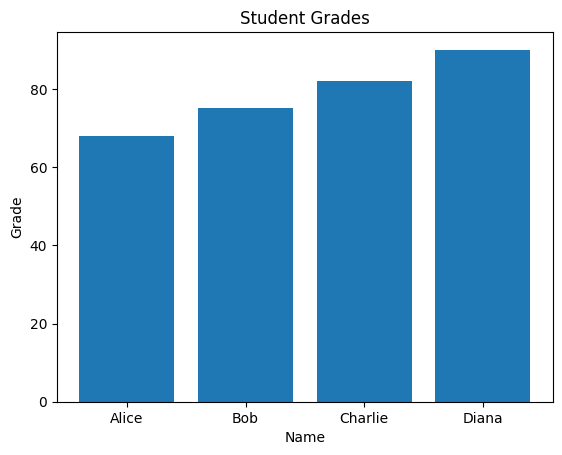

In [11]:
# Simple bar chart: names on x-axis, grades on y-axis
plt.bar(df["name"], df["grade"])
plt.xlabel("Name")
plt.ylabel("Grade")
plt.title("Student Grades")
plt.show()

### Step 2.7: Create sample datasets (CSV and JSON)

In [12]:
# Create a student grades CSV file
student_data = {
    'student_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve',
             'Frank', 'Grace', 'Henry', 'Iris', 'Jack'],
    'age': [20, 22, 21, 23, 20, 22, 21, 24, 20, 23],
    'math_score': [85, 72, 90, 88, 76, 95, 82, 79, 91, 84],
    'science_score': [78, 85, 88, 92, 81, 89, 87, 75, 94, 80],
    'attendance': [95, 87, 92, 98, 85, 97, 90, 82, 96, 88]
}

df_students = pd.DataFrame(student_data)
df_students.to_csv('students.csv', index=False)  # index=False avoids writing row numbers
print("Created students.csv")
print(df_students.head())

Created students.csv
   student_id     name  age  math_score  science_score  attendance
0           1    Alice   20          85             78          95
1           2      Bob   22          72             85          87
2           3  Charlie   21          90             88          92
3           4    Diana   23          88             92          98
4           5      Eve   20          76             81          85


In [13]:
# Create a weather JSON file
weather_data = {
    'city': ['Limerick', 'Galway', 'Dublin', 'Cork', 'Belfast'],
    'temperature': [12.5, 11.8, 13.2, 13.8, 10.9],
    'humidity': [82, 85, 78, 80, 88],
    'wind_speed': [15.2, 18.5, 12.3, 14.1, 20.3],
    'rainfall_mm': [2.3, 3.1, 1.8, 2.0, 3.8]
}

df_weather = pd.DataFrame(weather_data)
df_weather.to_json('weather.json', orient='records', indent=2)
print("Created weather.json")
print(df_weather)

Created weather.json
       city  temperature  humidity  wind_speed  rainfall_mm
0  Limerick         12.5        82        15.2          2.3
1    Galway         11.8        85        18.5          3.1
2    Dublin         13.2        78        12.3          1.8
3      Cork         13.8        80        14.1          2.0
4   Belfast         10.9        88        20.3          3.8


### Step 2.8: Load and explore data from files

In [14]:
# Load CSV — pd.read_csv() is the most common way to load data
students_df = pd.read_csv('students.csv')

# .head() shows the first 5 rows
print("First few rows:")
print(students_df.head())

First few rows:
   student_id     name  age  math_score  science_score  attendance
0           1    Alice   20          85             78          95
1           2      Bob   22          72             85          87
2           3  Charlie   21          90             88          92
3           4    Diana   23          88             92          98
4           5      Eve   20          76             81          85


In [15]:
# .info() shows column types and null counts
# .describe() gives summary statistics (mean, std, min, max, etc.)
print("DataFrame info:")
print(students_df.info())

print("\nBasic statistics:")
print(students_df.describe())

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   student_id     10 non-null     int64
 1   name           10 non-null     str  
 2   age            10 non-null     int64
 3   math_score     10 non-null     int64
 4   science_score  10 non-null     int64
 5   attendance     10 non-null     int64
dtypes: int64(5), str(1)
memory usage: 612.0 bytes
None

Basic statistics:
       student_id        age  math_score  science_score  attendance
count    10.00000  10.000000   10.000000      10.000000   10.000000
mean      5.50000  21.600000   84.200000      84.900000   91.000000
std       3.02765   1.429841    7.146095       6.226288    5.477226
min       1.00000  20.000000   72.000000      75.000000   82.000000
25%       3.25000  20.250000   79.750000      80.250000   87.250000
50%       5.50000  21.500000   84.500000      86.000000   91.000000
75%    

In [16]:
# Load JSON — works the same way
weather_df = pd.read_json('weather.json')
print("Weather DataFrame:")
print(weather_df)
print("\nColumn data types:")
print(weather_df.dtypes)

Weather DataFrame:
       city  temperature  humidity  wind_speed  rainfall_mm
0  Limerick         12.5        82        15.2          2.3
1    Galway         11.8        85        18.5          3.1
2    Dublin         13.2        78        12.3          1.8
3      Cork         13.8        80        14.1          2.0
4   Belfast         10.9        88        20.3          3.8

Column data types:
city               str
temperature    float64
humidity         int64
wind_speed     float64
rainfall_mm    float64
dtype: object


### Step 2.9: Data Wrangling — creating new columns, filtering, grouping

In [17]:
# Create a new column by computing from existing columns
students_df['average_score'] = (students_df['math_score'] +
                                students_df['science_score']) / 2

print("Students with average scores:")
print(students_df[['name', 'math_score', 'science_score', 'average_score']])

Students with average scores:
      name  math_score  science_score  average_score
0    Alice          85             78           81.5
1      Bob          72             85           78.5
2  Charlie          90             88           89.0
3    Diana          88             92           90.0
4      Eve          76             81           78.5
5    Frank          95             89           92.0
6    Grace          82             87           84.5
7    Henry          79             75           77.0
8     Iris          91             94           92.5
9     Jack          84             80           82.0


In [18]:
# Filter: boolean indexing to get rows matching a condition
high_performers = students_df[students_df['average_score'] > 85]

print(f"High performers (avg > 85): {len(high_performers)} students")
print(high_performers[['name', 'average_score']])

High performers (avg > 85): 4 students
      name  average_score
2  Charlie           89.0
3    Diana           90.0
5    Frank           92.0
8     Iris           92.5


In [19]:
# Groupby: split data by a column, then aggregate
# .agg() lets you specify different functions for different columns
age_groups = students_df.groupby('age').agg({
    'math_score': 'mean',
    'science_score': 'mean',
    'attendance': 'mean'
}).round(2)

print("Average scores by age:")
print(age_groups)

Average scores by age:
     math_score  science_score  attendance
age                                       
20         84.0          84.33        92.0
21         86.0          87.50        91.0
22         83.5          87.00        92.0
23         86.0          86.00        93.0
24         79.0          75.00        82.0


### Step 2.10: Handling missing data (NaN values)

In [20]:
# Artificially introduce some missing values to demonstrate
students_with_missing = students_df.copy()
students_with_missing.loc[2, 'math_score'] = np.nan
students_with_missing.loc[5, 'science_score'] = np.nan
students_with_missing.loc[7, 'attendance'] = np.nan

# .isnull().sum() counts NaN values per column
print("Missing values per column:")
print(students_with_missing.isnull().sum())

Missing values per column:
student_id       0
name             0
age              0
math_score       1
science_score    1
attendance       1
average_score    0
dtype: int64


In [21]:
# Option 1: fillna() — replace NaN with a value (here, the column mean)
students_filled = students_with_missing.fillna(
    students_with_missing[['math_score', 'science_score', 'attendance']].mean()
)
print("After filling with mean:")
print(students_filled)

# Option 2: dropna() — remove rows that contain any NaN
students_dropped = students_with_missing.dropna()
print(f"\nRows after dropping NaN: {len(students_dropped)} (was {len(students_with_missing)})")

After filling with mean:
   student_id     name  age  math_score  science_score  attendance  \
0           1    Alice   20   85.000000      78.000000        95.0   
1           2      Bob   22   72.000000      85.000000        87.0   
2           3  Charlie   21   83.555556      88.000000        92.0   
3           4    Diana   23   88.000000      92.000000        98.0   
4           5      Eve   20   76.000000      81.000000        85.0   
5           6    Frank   22   95.000000      84.444444        97.0   
6           7    Grace   21   82.000000      87.000000        90.0   
7           8    Henry   24   79.000000      75.000000        92.0   
8           9     Iris   20   91.000000      94.000000        96.0   
9          10     Jack   23   84.000000      80.000000        88.0   

   average_score  
0           81.5  
1           78.5  
2           89.0  
3           90.0  
4           78.5  
5           92.0  
6           84.5  
7           77.0  
8           92.5  
9           82

### Step 2.11: Merging DataFrames

In [22]:
# Create a second DataFrame with city info
city_info = pd.DataFrame({
    'city': ['Limerick', 'Galway', 'Dublin', 'Cork', 'Belfast'],
    'population': [94192, 79934, 554554, 208669, 343542],
    'province': ['Munster', 'Connacht', 'Leinster', 'Munster', 'Ulster']
})

# pd.merge() joins two DataFrames on a shared column
# on='city' means: match rows where the 'city' column is the same
weather_merged = pd.merge(weather_df, city_info, on='city')

print("Merged weather data:")
print(weather_merged)

Merged weather data:
       city  temperature  humidity  wind_speed  rainfall_mm  population  \
0  Limerick         12.5        82        15.2          2.3       94192   
1    Galway         11.8        85        18.5          3.1       79934   
2    Dublin         13.2        78        12.3          1.8      554554   
3      Cork         13.8        80        14.1          2.0      208669   
4   Belfast         10.9        88        20.3          3.8      343542   

   province  
0   Munster  
1  Connacht  
2  Leinster  
3   Munster  
4    Ulster  


### Step 2.12: Exercise — new columns and conditional logic

1. Calculate temperature-to-humidity ratio
2. Find the city with highest rainfall
3. Create a 'Windy'/'Calm' category column

In [23]:
# 1. New column from arithmetic on existing columns
weather_merged['temp_humidity_ratio'] = weather_merged['temperature'] / weather_merged['humidity']

# 2. Boolean indexing: find row where rainfall_mm equals its max
max_rain = weather_merged[weather_merged['rainfall_mm'] == weather_merged['rainfall_mm'].max()]
print("Highest rainfall city:", max_rain['city'].values[0])

# 3. np.where(condition, value_if_true, value_if_false) — like a ternary
weather_merged['category'] = np.where(weather_merged['wind_speed'] > 15, 'Windy', 'Calm')
weather_merged

Highest rainfall city: Belfast


,city,temperature,humidity,wind_speed,rainfall_mm,population,province,temp_humidity_ratio,category
0,Limerick,12.5,82,15.2,2.3,94192,Munster,0.152439,Windy
1,Galway,11.8,85,18.5,3.1,79934,Connacht,0.138824,Windy
2,Dublin,13.2,78,12.3,1.8,554554,Leinster,0.169231,Calm
3,Cork,13.8,80,14.1,2.0,208669,Munster,0.172500,Calm
4,Belfast,10.9,88,20.3,3.8,343542,Ulster,0.123864,Windy


### Step 2.13: Exercise — Student grade assignment with np.select

Assign letter grades based on average score thresholds.

In [24]:
# np.select takes a list of conditions and a list of corresponding values
# It returns the value matching the FIRST true condition for each row
conditions = [
    students_df['average_score'] >= 90,
    students_df['average_score'] >= 85,
    students_df['average_score'] >= 80,
    students_df['average_score'] < 80
]
choices = ['A', 'B', 'C', 'D']

# NumPy 2.x requires compatible dtypes for choices and default
students_df['grade'] = np.select(conditions, choices, default='D')

# .value_counts() counts occurrences of each unique value
print("Grade distribution:")
print(students_df['grade'].value_counts())

# Find student(s) with highest attendance
best_attendance = students_df[students_df['attendance'] == students_df['attendance'].max()]
print("\nHighest attendance:")
print(best_attendance[['name', 'attendance']])

# Correlation between math and science scores
corr = students_df['math_score'].corr(students_df['science_score'])
print(f"\nCorrelation (math vs science): {corr:.3f}")

Grade distribution:
grade
C    3
D    3
A    3
B    1
Name: count, dtype: int64

Highest attendance:
    name  attendance
3  Diana          98

Correlation (math vs science): 0.560


### Step 2.14: Exercise — Load people.csv and devices.json

These files were provided on Moodle. Load and inspect them.

In [25]:
# Load external datasets
people_df = pd.read_csv('people.csv')
devices_df = pd.read_json('devices.json')

print("People:")
print(people_df.head())
print("\nDevices:")
print(devices_df.head())

People:
      name  age  height_cm    city
0    Alice   23        165  Dublin
1      Bob   35        180  Galway
2  Charlie   29        175    Cork
3     Dana   41        160  Dublin

Devices:
   id    type  active  value
0   1  sensor    True   12.3
1   2  sensor   False    7.8
2   3  camera    True    NaN


---
## Part 3: Visualisation with Matplotlib

Core plot types you need to know:
- `plt.plot()` — line plot
- `plt.bar()` — bar chart
- `plt.scatter()` — scatter plot
- `plt.hist()` — histogram
- `plt.imshow()` — display images
- `plt.subplots()` — multiple plots in one figure

### Step 3.1: Line plot — comparing two series

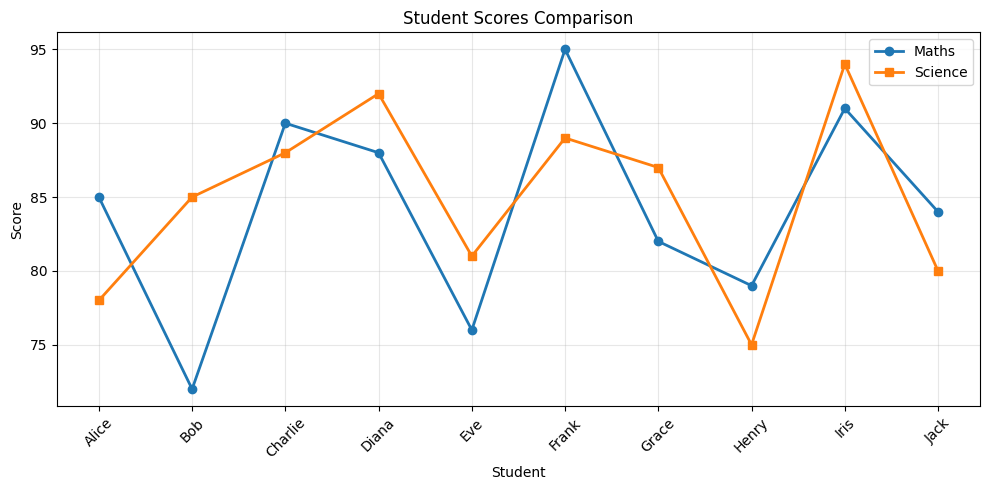

In [26]:
# Line plot with markers
plt.figure(figsize=(10, 5))
plt.plot(students_df['name'], students_df['math_score'],
         marker='o', label='Maths', linewidth=2)
plt.plot(students_df['name'], students_df['science_score'],
         marker='s', label='Science', linewidth=2)
plt.xlabel('Student')
plt.ylabel('Score')
plt.title('Student Scores Comparison')
plt.legend()             # Show the legend (uses the label= from above)
plt.xticks(rotation=45)  # Rotate x labels so they don't overlap
plt.grid(True, alpha=0.3)
plt.tight_layout()       # Prevent labels from being cut off
plt.show()

### Step 3.2: Bar charts with subplots

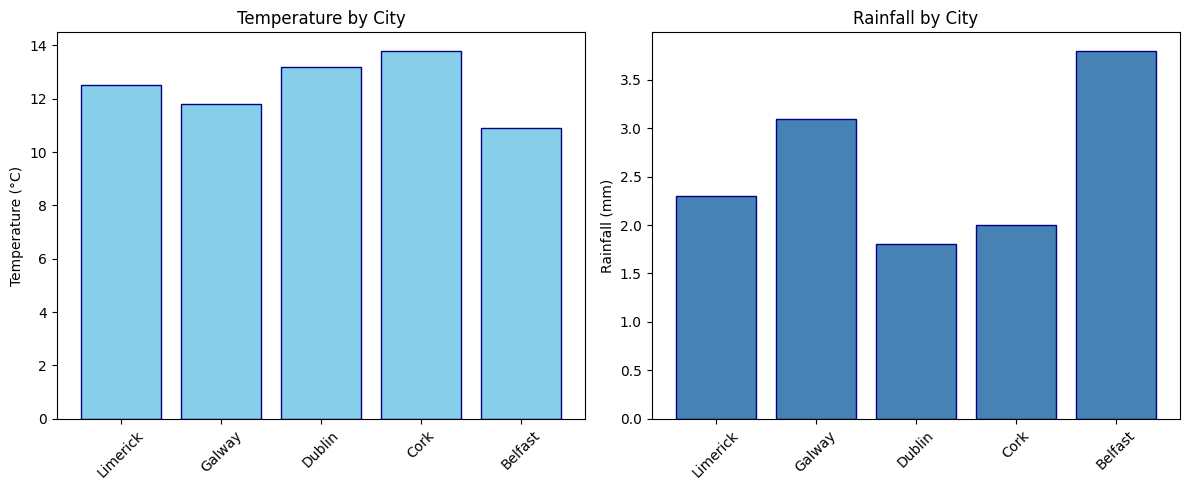

In [27]:
# plt.subplots(rows, cols) creates a figure with multiple axes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: temperature
axes[0].bar(weather_merged['city'], weather_merged['temperature'],
            color='skyblue', edgecolor='navy')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Temperature by City')
axes[0].tick_params(axis='x', rotation=45)

# Right: rainfall
axes[1].bar(weather_merged['city'], weather_merged['rainfall_mm'],
            color='steelblue', edgecolor='darkblue')
axes[1].set_ylabel('Rainfall (mm)')
axes[1].set_title('Rainfall by City')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Step 3.3: Scatter plot with trend line

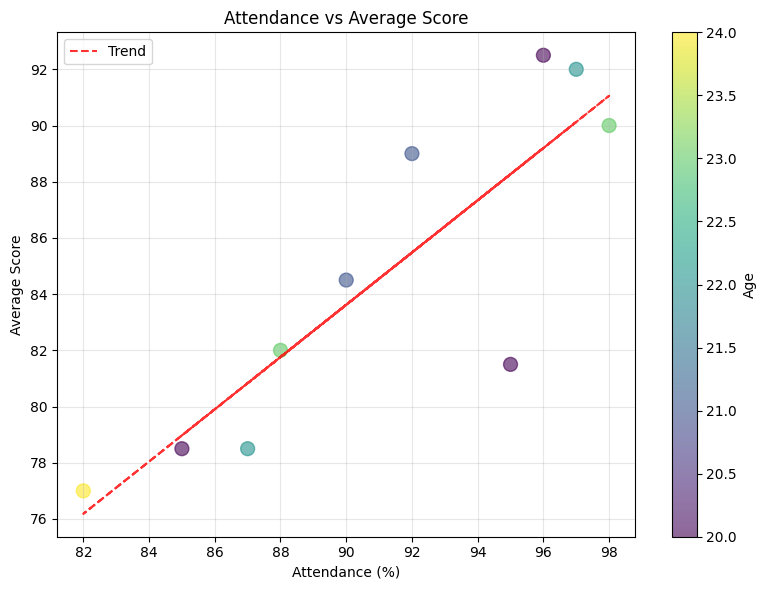

In [28]:
plt.figure(figsize=(8, 6))

# Scatter: each point is a student; colour = age
plt.scatter(students_df['attendance'], students_df['average_score'],
            s=100, alpha=0.6, c=students_df['age'], cmap='viridis')
plt.colorbar(label='Age')

# Add trend line using np.polyfit (degree 1 = linear)
z = np.polyfit(students_df['attendance'], students_df['average_score'], 1)
p = np.poly1d(z)  # Creates a polynomial function from coefficients
plt.plot(students_df['attendance'], p(students_df['attendance']),
         'r--', alpha=0.8, label='Trend')

plt.xlabel('Attendance (%)')
plt.ylabel('Average Score')
plt.title('Attendance vs Average Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 3.4: Histograms — showing distributions

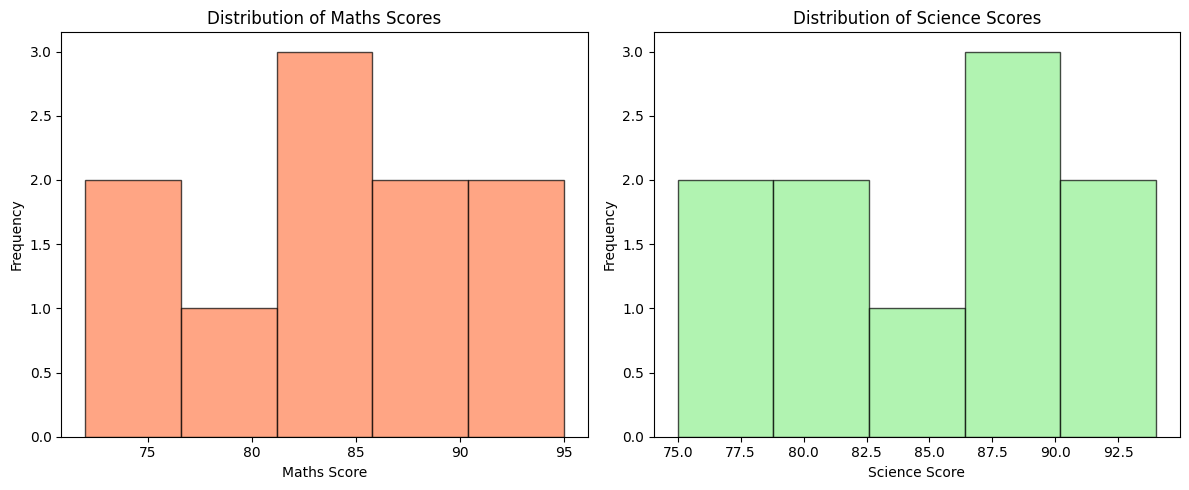

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# bins = number of bars the data is grouped into
axes[0].hist(students_df['math_score'], bins=5,
             color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Maths Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Maths Scores')

axes[1].hist(students_df['science_score'], bins=5,
             color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Science Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Science Scores')

plt.tight_layout()
plt.show()

### Step 3.5: Dashboard — combining multiple plot types

/tmp/ipykernel_14757/2101240443.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot([students_df['attendance'], students_df['math_score'],


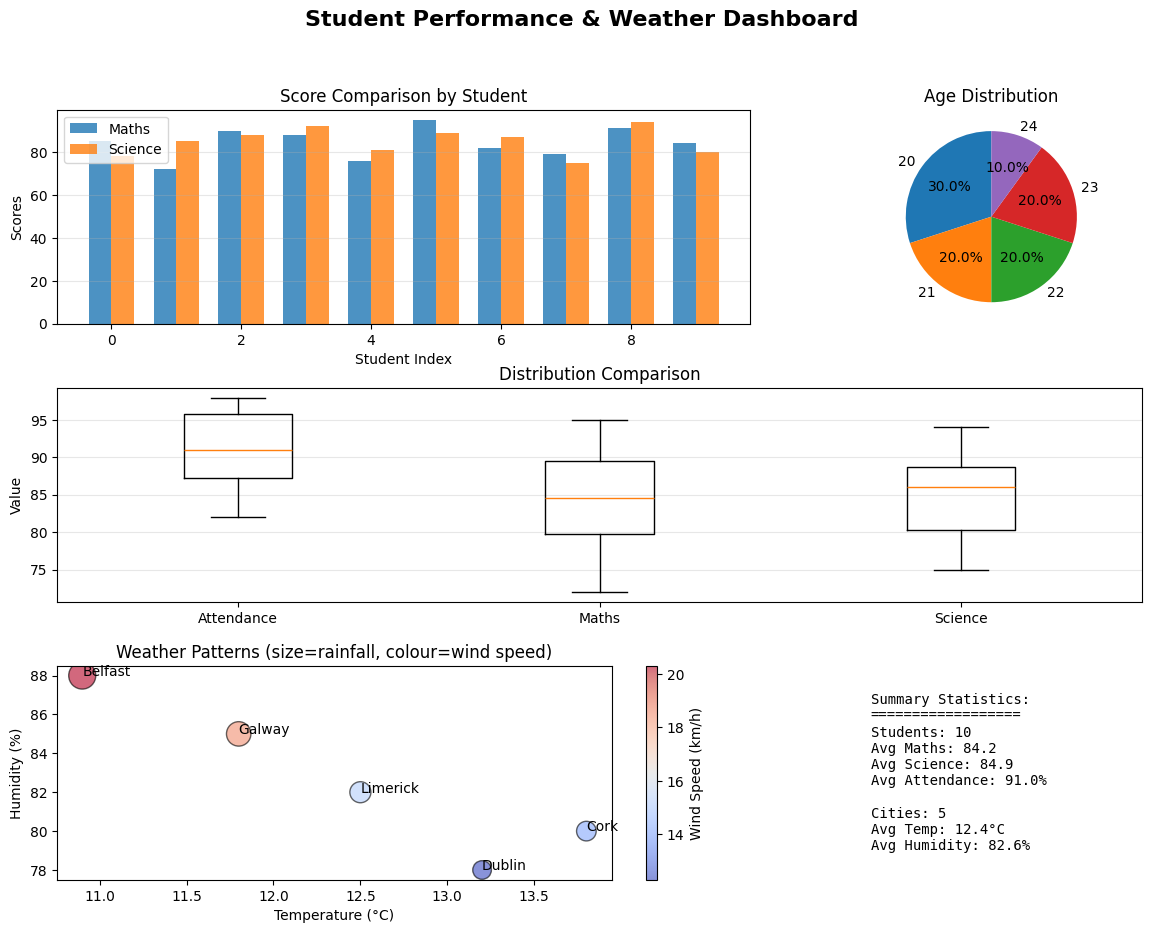

In [30]:
# fig.add_gridspec() gives fine control over subplot layout
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Grouped bar chart (spans 2 columns)
ax1 = fig.add_subplot(gs[0, :2])
x = np.arange(len(students_df))
width = 0.35
ax1.bar(x - width/2, students_df['math_score'], width, label='Maths', alpha=0.8)
ax1.bar(x + width/2, students_df['science_score'], width, label='Science', alpha=0.8)
ax1.set_xlabel('Student Index')
ax1.set_ylabel('Scores')
ax1.set_title('Score Comparison by Student')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Pie chart
ax2 = fig.add_subplot(gs[0, 2])
age_counts = students_df['age'].value_counts().sort_index()
ax2.pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Age Distribution')

# Plot 3: Box plot (shows median, quartiles, outliers)
ax3 = fig.add_subplot(gs[1, :])
ax3.boxplot([students_df['attendance'], students_df['math_score'],
             students_df['science_score']],
            labels=['Attendance', 'Maths', 'Science'])
ax3.set_ylabel('Value')
ax3.set_title('Distribution Comparison')
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Bubble scatter (size=rainfall, colour=wind speed)
ax4 = fig.add_subplot(gs[2, :2])
scatter = ax4.scatter(weather_merged['temperature'], weather_merged['humidity'],
                      s=weather_merged['rainfall_mm'] * 100,
                      c=weather_merged['wind_speed'],
                      cmap='coolwarm', alpha=0.6, edgecolors='black')
for i, city in enumerate(weather_merged['city']):
    ax4.annotate(city, (weather_merged['temperature'].iloc[i],
                        weather_merged['humidity'].iloc[i]))
ax4.set_xlabel('Temperature (°C)')
ax4.set_ylabel('Humidity (%)')
ax4.set_title('Weather Patterns (size=rainfall, colour=wind speed)')
plt.colorbar(scatter, ax=ax4, label='Wind Speed (km/h)')

# Plot 5: Text summary
ax5 = fig.add_subplot(gs[2, 2])
ax5.axis('off')
summary_text = f"""Summary Statistics:
==================
Students: {len(students_df)}
Avg Maths: {students_df['math_score'].mean():.1f}
Avg Science: {students_df['science_score'].mean():.1f}
Avg Attendance: {students_df['attendance'].mean():.1f}%

Cities: {len(weather_merged)}
Avg Temp: {weather_merged['temperature'].mean():.1f}°C
Avg Humidity: {weather_merged['humidity'].mean():.1f}%"""
ax5.text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
         verticalalignment='center')

plt.suptitle('Student Performance & Weather Dashboard', fontsize=16, fontweight='bold')
plt.show()

### Step 3.6: Exercise — weather subplot

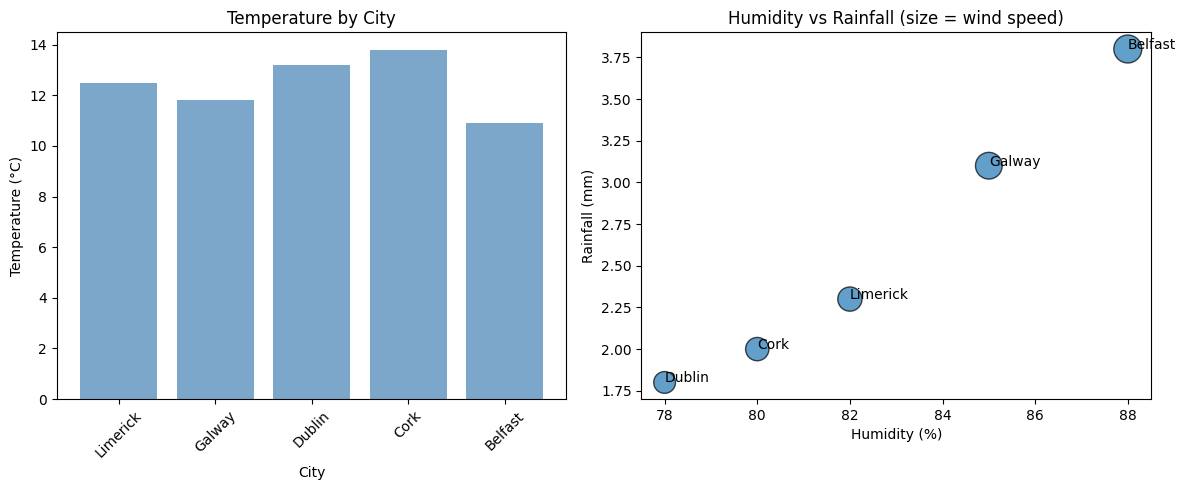

In [31]:
# Create two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: bar chart of temperature
ax1.bar(weather_merged['city'], weather_merged['temperature'], color='steelblue', alpha=0.7)
ax1.set_xlabel('City')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Temperature by City')
ax1.tick_params(axis='x', rotation=45)

# Right: scatter — humidity vs rainfall, point size = wind speed
ax2.scatter(weather_merged['humidity'], weather_merged['rainfall_mm'],
            s=weather_merged['wind_speed'] * 20, alpha=0.7, edgecolors='black')
for i, city in enumerate(weather_merged['city']):
    ax2.annotate(city, (weather_merged['humidity'].iloc[i],
                        weather_merged['rainfall_mm'].iloc[i]))
ax2.set_xlabel('Humidity (%)')
ax2.set_ylabel('Rainfall (mm)')
ax2.set_title('Humidity vs Rainfall (size = wind speed)')

plt.tight_layout()
plt.show()

---
## Part 4: Working with Images as NumPy Arrays

Key concept: an image is just a 3D numpy array with shape `(height, width, channels)`.
- Channels are typically RGB: Red, Green, Blue
- Pixel values range from 0–255 (uint8)
- For ML, we often normalise to 0.0–1.0

### Step 4.1: Create sample gradient images

In [32]:
from PIL import Image

# Create a 200x200 image where the red channel increases left to right
red_image = np.zeros((200, 200, 3), dtype=np.uint8)
for i in range(200):
    red_image[:, i] = [i, 0, 0]  # [R, G, B]

# Create a 200x200 image where the blue channel increases top to bottom
blue_image = np.zeros((200, 200, 3), dtype=np.uint8)
for i in range(200):
    blue_image[i, :] = [0, 0, i]

# Save using PIL
Image.fromarray(red_image).save('red_gradient.png')
Image.fromarray(blue_image).save('blue_gradient.png')
print("Created red_gradient.png and blue_gradient.png")

Created red_gradient.png and blue_gradient.png


### Step 4.2: Load and display images

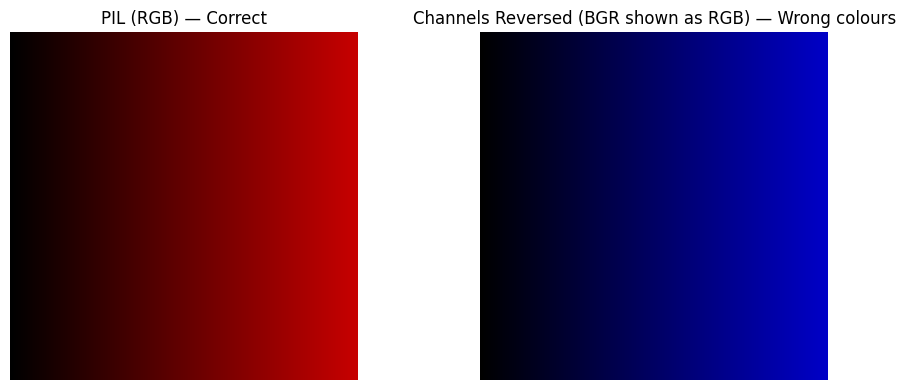

In [33]:
# Load image with PIL, convert to numpy array
pil_image = Image.open('red_gradient.png')
pil_array = np.array(pil_image)

# PIL uses RGB order. OpenCV uses BGR (reversed channels).
# To simulate BGR: reverse the channel axis
bgr_array = pil_array[:, :, ::-1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(pil_array)
axes[0].set_title('PIL (RGB) — Correct')
axes[0].axis('off')

axes[1].imshow(bgr_array)
axes[1].set_title('Channels Reversed (BGR shown as RGB) — Wrong colours')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Step 4.3: Image properties and pixel access

In [34]:
# Shape: (height, width, channels)
print(f"Shape: {pil_array.shape}")
print(f"Dtype: {pil_array.dtype}")
print(f"Pixel count: {pil_array.shape[0] * pil_array.shape[1]}")

# Access a single pixel: array[row, col] gives [R, G, B]
print(f"\nTop-left pixel: {pil_array[0, 0]}")
print(f"Top-right pixel: {pil_array[0, -1]}")

# Extract individual channels by slicing the 3rd dimension
print(f"\nRed channel shape: {pil_array[:, :, 0].shape}")

Shape: (200, 200, 3)
Dtype: uint8
Pixel count: 40000

Top-left pixel: [0 0 0]
Top-right pixel: [199   0   0]

Red channel shape: (200, 200)


### Step 4.4: Visualise individual colour channels

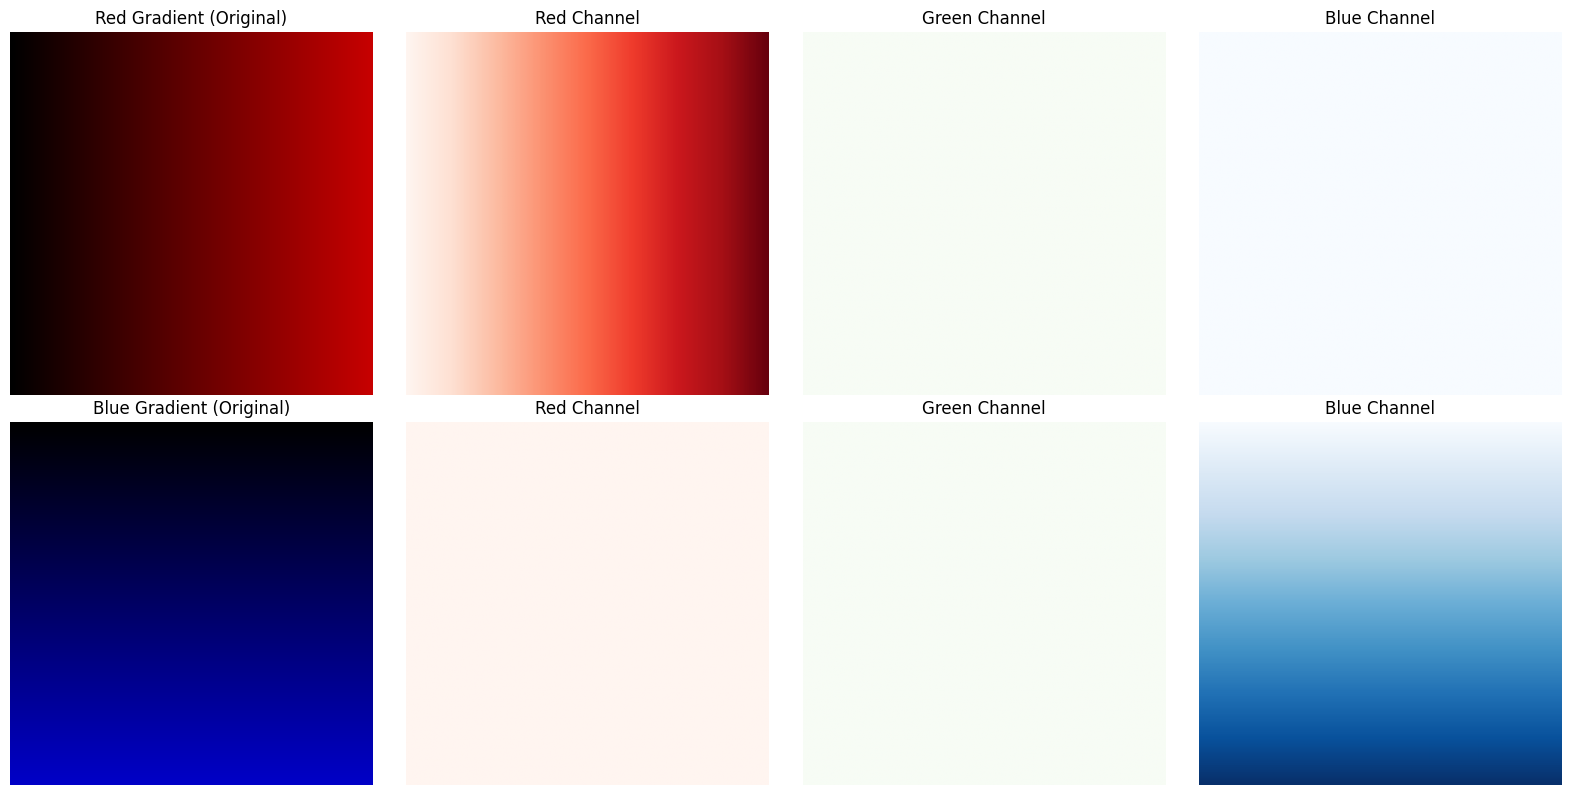

In [35]:
# Load blue gradient too
blue_array = np.array(Image.open('blue_gradient.png'))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Row 1: red gradient and its channels
axes[0, 0].imshow(pil_array)
axes[0, 0].set_title('Red Gradient (Original)')
axes[0, 0].axis('off')
axes[0, 1].imshow(pil_array[:, :, 0], cmap='Reds')
axes[0, 1].set_title('Red Channel')
axes[0, 1].axis('off')
axes[0, 2].imshow(pil_array[:, :, 1], cmap='Greens')
axes[0, 2].set_title('Green Channel')
axes[0, 2].axis('off')
axes[0, 3].imshow(pil_array[:, :, 2], cmap='Blues')
axes[0, 3].set_title('Blue Channel')
axes[0, 3].axis('off')

# Row 2: blue gradient and its channels
axes[1, 0].imshow(blue_array)
axes[1, 0].set_title('Blue Gradient (Original)')
axes[1, 0].axis('off')
axes[1, 1].imshow(blue_array[:, :, 0], cmap='Reds')
axes[1, 1].set_title('Red Channel')
axes[1, 1].axis('off')
axes[1, 2].imshow(blue_array[:, :, 1], cmap='Greens')
axes[1, 2].set_title('Green Channel')
axes[1, 2].axis('off')
axes[1, 3].imshow(blue_array[:, :, 2], cmap='Blues')
axes[1, 3].set_title('Blue Channel')
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

### Step 4.5: Exercise — pixel exploration

In [36]:
# Load red_gradient and inspect a specific pixel
red_img = np.array(Image.open('red_gradient.png'))

# Pixel at (row=100, col=100)
# Since red increases L→R, at column 100 we expect R≈100, G=0, B=0
pixel = red_img[100, 100]
print(f"Pixel at (100, 100): {pixel}")

# Extract red channel and find its max
red_channel = red_img[:, :, 0]
print(f"Red channel max: {red_channel.max()}")
print(f"Red channel shape: {red_channel.shape}")

Pixel at (100, 100): [100   0   0]
Red channel max: 199
Red channel shape: (200, 200)


### Step 4.6: Exercise — channel manipulation

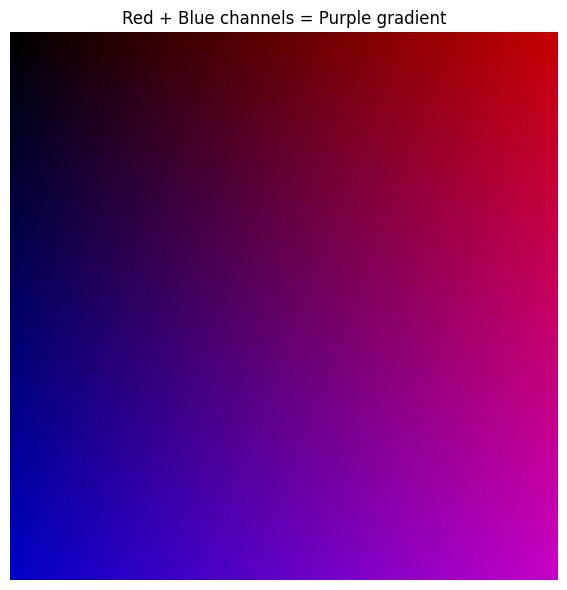

In [37]:
# Combine channels from different images into one new image
red_grad = np.array(Image.open('red_gradient.png'))
blue_grad = np.array(Image.open('blue_gradient.png'))

# Start with all zeros, then fill in R and B channels
new_image = np.zeros_like(red_grad)
new_image[:, :, 0] = red_grad[:, :, 0]   # Red from red gradient
new_image[:, :, 2] = blue_grad[:, :, 2]  # Blue from blue gradient
# Green stays 0 → result should be purple/magenta

plt.figure(figsize=(8, 6))
plt.imshow(new_image.astype(np.uint8))
plt.title('Red + Blue channels = Purple gradient')
plt.axis('off')
plt.tight_layout()
plt.show()

### Step 4.7: Normalisation — converting pixel values from [0, 255] to [0, 1]

Most ML models expect inputs in [0, 1] not [0, 255].

In [38]:
img_255 = np.array(Image.open('red_gradient.png'))
print(f"Original — Min: {img_255.min()}, Max: {img_255.max()}, Dtype: {img_255.dtype}")

# Method 1: divide by 255 (simple and common)
img_01 = img_255 / 255.0
print(f"Normalised — Min: {img_01.min():.3f}, Max: {img_01.max():.3f}, Dtype: {img_01.dtype}")

# Method 2: sklearn's MinMaxScaler (useful for non-image data too)
from sklearn.preprocessing import MinMaxScaler
# MinMaxScaler expects 2D input, so reshape: (pixels, channels)
flat = img_255.reshape(-1, 3).astype(float)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(flat).reshape(img_255.shape)
print(f"Sklearn — Min: {scaled.min():.3f}, Max: {scaled.max():.3f}")

Original — Min: 0, Max: 199, Dtype: uint8
Normalised — Min: 0.000, Max: 0.780, Dtype: float64


Sklearn — Min: 0.000, Max: 1.000


### Step 4.8: Image transformations

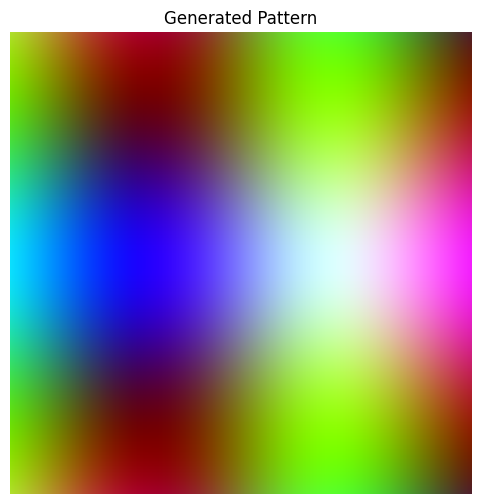

In [39]:
# Create a pattern image using trigonometric functions
height, width = 300, 300
x, y = np.meshgrid(np.linspace(-2, 2, width), np.linspace(-2, 2, height))

r = (np.sin(x) * np.cos(y) + 1) / 2
g = (np.sin(x * 2) + 1) / 2
b = (np.cos(y * 2) + 1) / 2

pattern_img = np.dstack([r, g, b])
pattern_img = (pattern_img * 255).astype(np.uint8)
Image.fromarray(pattern_img).save('pattern.png')

plt.figure(figsize=(6, 6))
plt.imshow(pattern_img)
plt.title('Generated Pattern')
plt.axis('off')
plt.show()

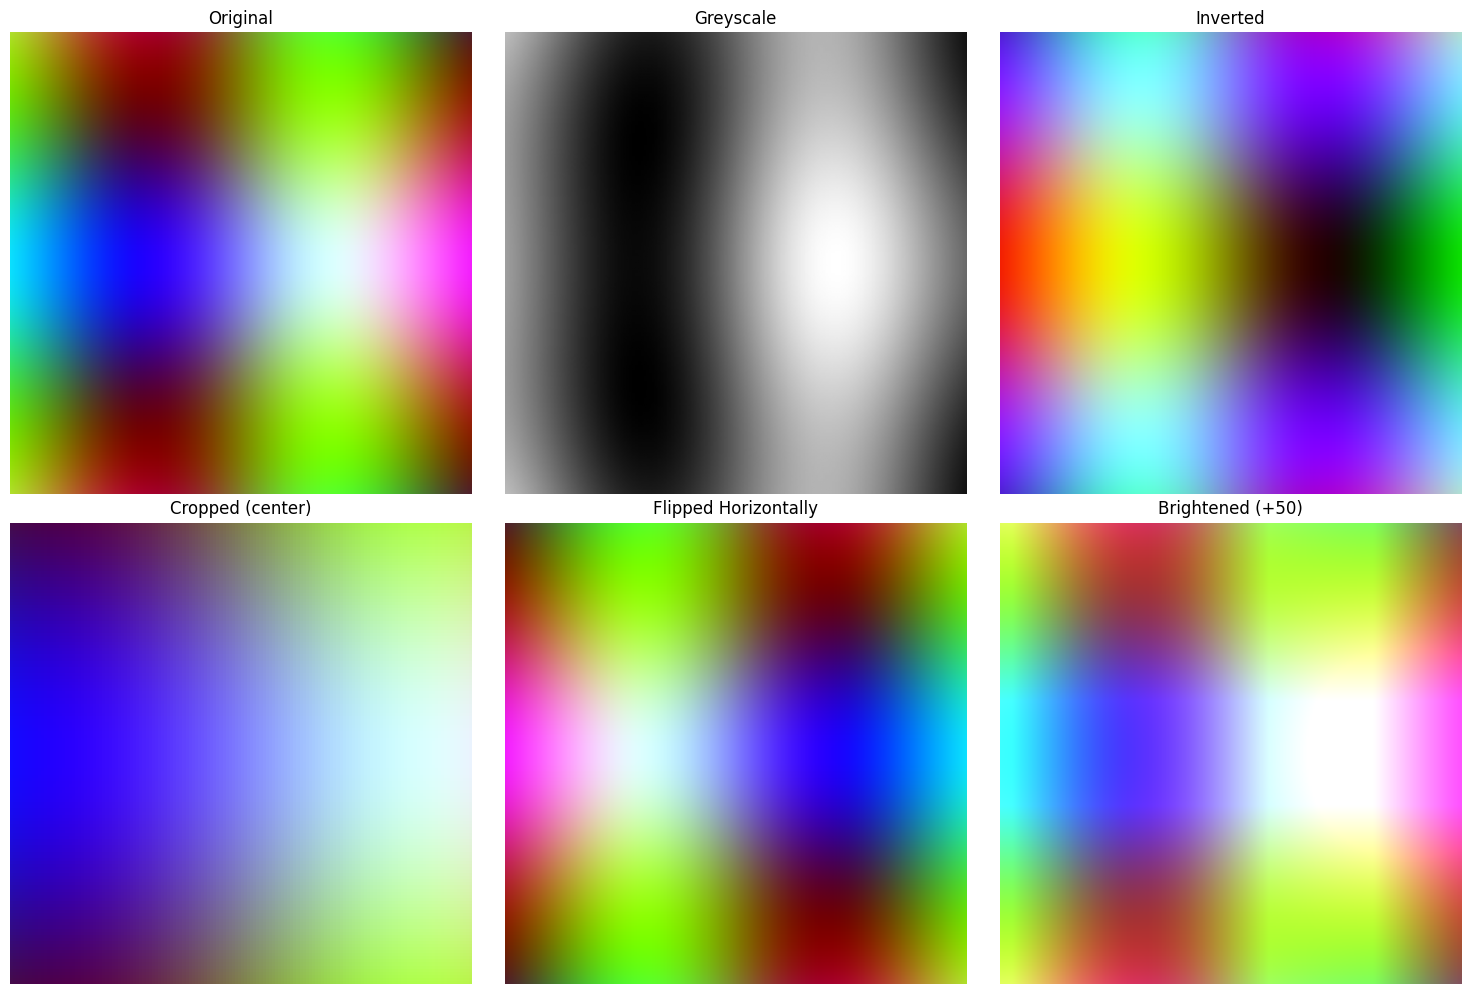

In [40]:
# Common transformations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0, 0].imshow(pattern_img)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Greyscale using luminosity formula: 0.299R + 0.587G + 0.114B
gray = (0.299 * pattern_img[:, :, 0] +
        0.587 * pattern_img[:, :, 1] +
        0.114 * pattern_img[:, :, 2])
axes[0, 1].imshow(gray, cmap='gray')
axes[0, 1].set_title('Greyscale')
axes[0, 1].axis('off')

# Inverted (negative)
inverted = 255 - pattern_img
axes[0, 2].imshow(inverted)
axes[0, 2].set_title('Inverted')
axes[0, 2].axis('off')

# Cropped (center 150x150)
h, w = pattern_img.shape[:2]
crop = pattern_img[h//4:3*h//4, w//4:3*w//4]
axes[1, 0].imshow(crop)
axes[1, 0].set_title('Cropped (center)')
axes[1, 0].axis('off')

# Flipped horizontally
flipped = pattern_img[:, ::-1]
axes[1, 1].imshow(flipped)
axes[1, 1].set_title('Flipped Horizontally')
axes[1, 1].axis('off')

# Brightened (clip to 255 to avoid overflow)
bright = np.clip(pattern_img.astype(np.int16) + 50, 0, 255).astype(np.uint8)
axes[1, 2].imshow(bright)
axes[1, 2].set_title('Brightened (+50)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### Step 4.9: Exercise — rotate, dim, remove channel

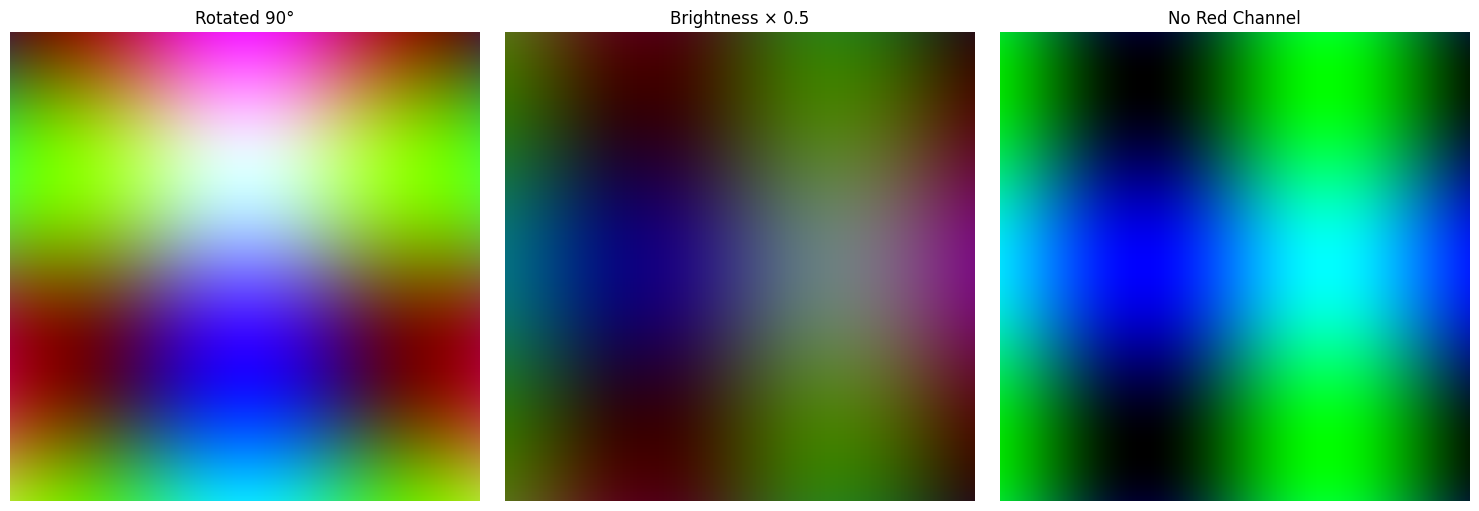

In [41]:
pattern = np.array(Image.open('pattern.png'))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Rotate 90°
rotated = np.rot90(pattern)
axes[0].imshow(rotated)
axes[0].set_title('Rotated 90°')
axes[0].axis('off')

# 2. Reduce brightness by 50%
dim = (pattern * 0.5).astype(np.uint8)
axes[1].imshow(dim)
axes[1].set_title('Brightness × 0.5')
axes[1].axis('off')

# 3. Remove red channel
no_red = pattern.copy()
no_red[:, :, 0] = 0
axes[2].imshow(no_red)
axes[2].set_title('No Red Channel')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Step 4.10: Exercise — vintage/sepia filter

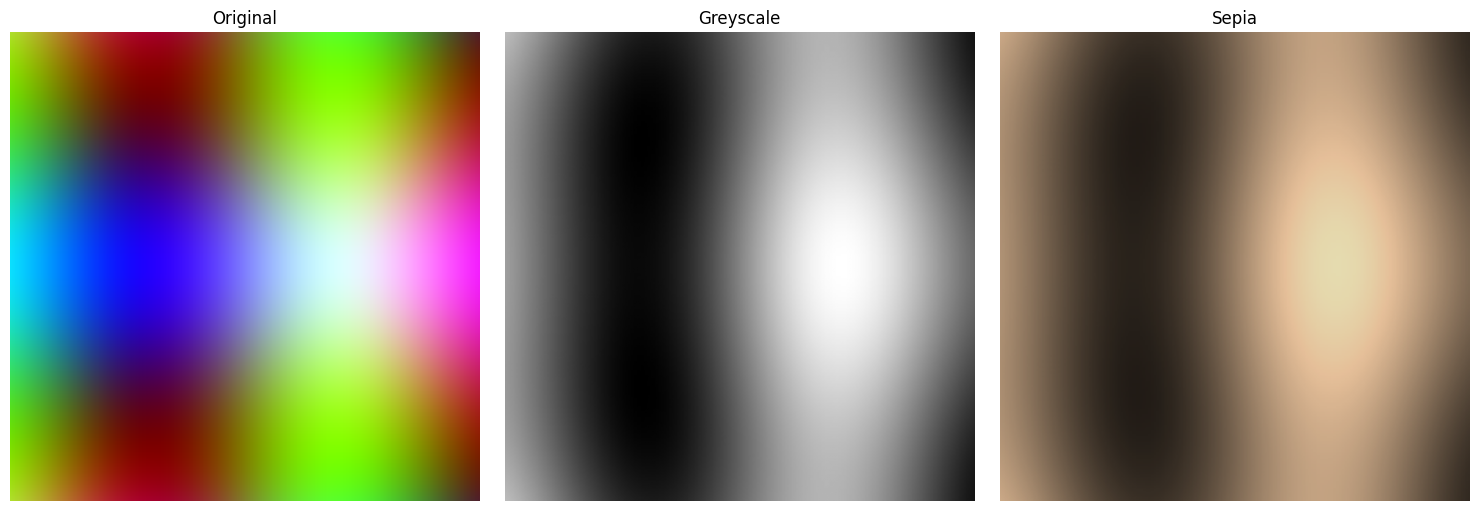

In [42]:
pattern = np.array(Image.open('pattern.png'))

# 1. Convert to greyscale
gray = (0.299 * pattern[:, :, 0] +
        0.587 * pattern[:, :, 1] +
        0.114 * pattern[:, :, 2])

# 2. Sepia tone: boost red, keep green, reduce blue
sepia = np.zeros_like(pattern)
sepia[:, :, 0] = np.clip(gray * 1.2, 0, 255).astype(np.uint8)  # R
sepia[:, :, 1] = gray.astype(np.uint8)                          # G
sepia[:, :, 2] = np.clip(gray * 0.8, 0, 255).astype(np.uint8)  # B

# 3. Reduce brightness by 10%
sepia = (sepia * 0.9).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(pattern)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Greyscale')
axes[1].axis('off')
axes[2].imshow(sepia)
axes[2].set_title('Sepia')
axes[2].axis('off')
plt.tight_layout()
plt.show()

### Step 4.11: Exercise — apply filters to a real image (353.jpg)

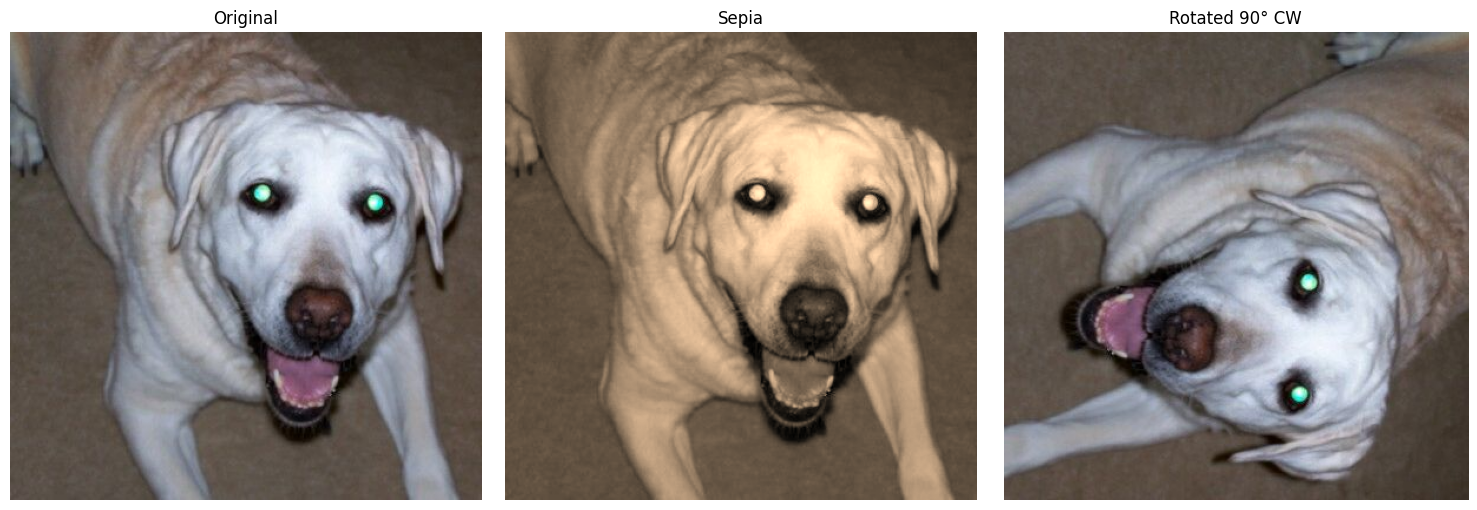

In [43]:
# Load the dog image
img_dog = np.array(Image.open('353.jpg'))

# Sepia filter
gray_dog = (0.299 * img_dog[:, :, 0] +
            0.587 * img_dog[:, :, 1] +
            0.114 * img_dog[:, :, 2]).astype(np.uint8)

sepia_dog = np.zeros_like(img_dog)
sepia_dog[:, :, 0] = np.clip(gray_dog * 1.2, 0, 255).astype(np.uint8)
sepia_dog[:, :, 1] = gray_dog
sepia_dog[:, :, 2] = np.clip(gray_dog * 0.8, 0, 255).astype(np.uint8)

# Rotate 90° clockwise (k=-1)
rotated_dog = np.rot90(img_dog, k=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_dog)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(sepia_dog)
axes[1].set_title('Sepia')
axes[1].axis('off')
axes[2].imshow(rotated_dog)
axes[2].set_title('Rotated 90° CW')
axes[2].axis('off')
plt.tight_layout()
plt.show()

---
## Part 5: Introduction to Scikit-learn

**The sklearn workflow (same for every model):**
1. **Import** the model class
2. **Instantiate** the model (set hyperparameters)
3. **Fit** the model to training data — `model.fit(X_train, y_train)`
4. **Predict** on new data — `model.predict(X_test)`
5. **Evaluate** performance — compare predictions to actual values

### Step 5.1: Imports

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Step 5.2: Feature scaling with StandardScaler

StandardScaler transforms each feature to have mean=0, std=1.
This is important when features have very different scales.

In [45]:
# Extract features as a numpy array
X = df[['age', 'grade']].values

# fit_transform: learn mean/std from data, then apply the transformation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original:")
print(X)
print("\nScaled (mean≈0, std≈1):")
print(X_scaled)

Original:
[[21 68]
 [23 75]
 [22 82]
 [24 90]]

Scaled (mean≈0, std≈1):
[[-1.34164079 -1.31639507]
 [ 0.4472136  -0.45920758]
 [-0.4472136   0.3979799 ]
 [ 1.34164079  1.37762274]]


### Step 5.3: K-Means clustering (unsupervised)

In [46]:
# K-Means groups data into k clusters based on distance
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X_scaled)

# Each point gets a cluster label (0 or 1)
print("Cluster labels:", kmeans.labels_)

Cluster labels: [0 0 0 1]


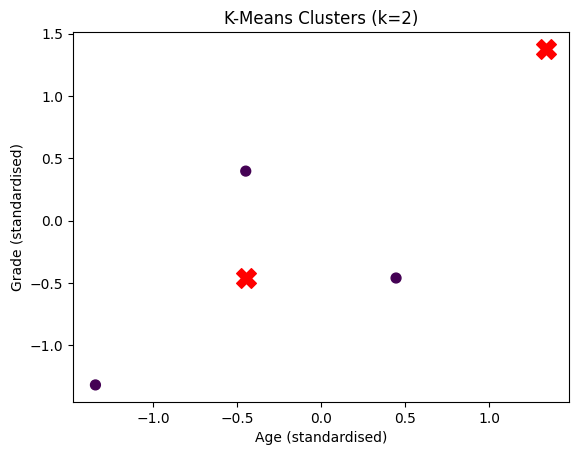

In [47]:
# Visualise clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, s=50)

# Plot cluster centres
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], s=200, marker='X', c='red')

plt.xlabel('Age (standardised)')
plt.ylabel('Grade (standardised)')
plt.title('K-Means Clusters (k=2)')
plt.show()

### Step 5.4: Why scaling matters

Without scaling, features with larger ranges dominate the distance calculation.

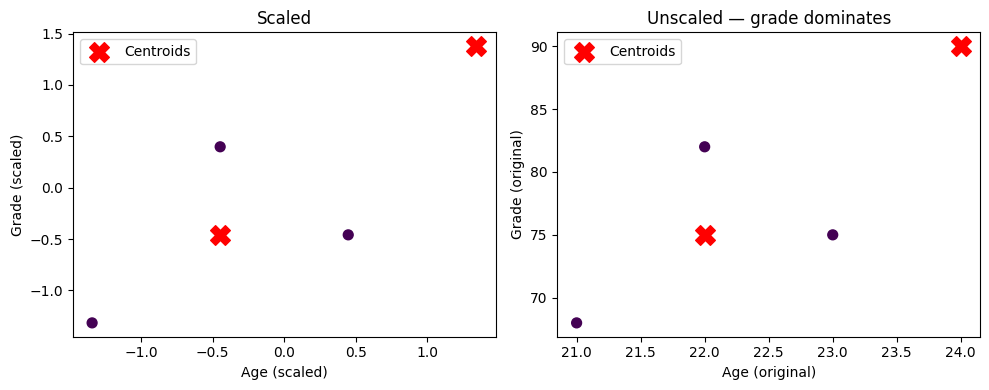

In [48]:
plt.figure(figsize=(10, 4))

# Left: scaled data
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, marker='X', c='red', label='Centroids')
plt.xlabel('Age (scaled)')
plt.ylabel('Grade (scaled)')
plt.title('Scaled')
plt.legend()

# Right: original (unscaled) data — notice the axes have very different ranges
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=50, cmap='viridis')
plt.scatter(centers_orig[:, 0], centers_orig[:, 1],
            s=200, marker='X', c='red', label='Centroids')
plt.xlabel('Age (original)')
plt.ylabel('Grade (original)')
plt.title('Unscaled — grade dominates')
plt.legend()

plt.tight_layout()
plt.show()

### Step 5.5: Linear Regression (supervised)

Predict science score from math score and attendance.

In [49]:
# Define features (X) and target (y)
X = students_df[['math_score', 'attendance']]  # 2D: each row is [math, attendance]
y = students_df['science_score']                # 1D: what we want to predict

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (10, 2)
Target shape: (10,)


In [50]:
# Split into training and testing sets
# test_size=0.3 means 30% of data goes to test, 70% to train
# random_state makes the split reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 7
Testing samples: 3


In [51]:
# The sklearn workflow: instantiate → fit → predict → evaluate
model = LinearRegression()
model.fit(X_train, y_train)       # Learn from training data
y_pred = model.predict(X_test)    # Predict on unseen test data

# Evaluate
mse = mean_squared_error(y_test, y_pred)  # Average squared error
r2 = r2_score(y_test, y_pred)             # R² = how much variance is explained (1.0 = perfect)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.3f}")

# Compare predictions vs actual
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred.round(1),
    'Difference': (y_test.values - y_pred).round(1)
})
print("\nPredictions vs Actual:")
print(comparison)

Mean Squared Error: 25.70
R² Score: -0.896

Predictions vs Actual:
   Actual  Predicted  Difference
0      94       88.3         5.7
1      85       78.4         6.6
2      89       89.9        -0.9


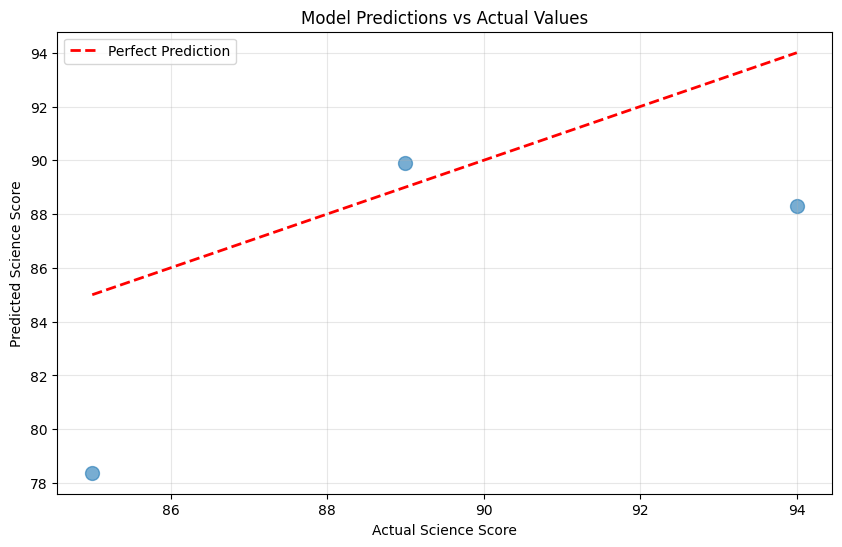

Coefficients: [0.25778363 0.55777372]
Intercept: 11.29

Equation: Science = 11.3 + 0.26 × Maths + 0.56 × Attendance


In [52]:
# Visualise: predicted vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, s=100)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Science Score')
plt.ylabel('Predicted Science Score')
plt.title('Model Predictions vs Actual Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Interpret the model coefficients
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"\nEquation: Science = {model.intercept_:.1f} "
      f"+ {model.coef_[0]:.2f} × Maths + {model.coef_[1]:.2f} × Attendance")

### Step 5.6: Classification example (Decision Tree)

Binary classification: predict whether a student is a high performer (avg > 85).

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create a binary target: 1 = high performer, 0 = not
students_df['performance'] = (students_df['average_score'] > 85).astype(int)
print("Class distribution:")
print(students_df['performance'].value_counts())

# Features and target
X_class = students_df[['math_score', 'attendance']]
y_class = students_df['performance']

# Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42
)

# Train and evaluate
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

print(f"\nAccuracy: {accuracy_score(y_test_c, y_pred_c):.2f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))

Class distribution:
performance
0    6
1    4
Name: count, dtype: int64

Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



### Step 5.7: Using sklearn with image data — K-Means colour quantisation

Reduce an image to k dominant colours using clustering.

In [54]:
from sklearn.cluster import KMeans

# Load image and reshape: (H, W, 3) → (H*W, 3)
# Each row becomes one pixel's [R, G, B]
img = np.array(Image.open('pattern.png'))
pixels = img.reshape(-1, 3)
pixels_norm = pixels / 255.0

print(f"Image shape: {img.shape}")
print(f"Reshaped to: {pixels.shape} (each row = 1 pixel)")

# Cluster pixels into 5 groups
n_colours = 5
kmeans = KMeans(n_clusters=n_colours, random_state=42, n_init=10)
kmeans.fit(pixels_norm)

# The cluster centres ARE the dominant colours
colours = kmeans.cluster_centers_
print(f"\nDominant colours (RGB 0-1):")
for i, c in enumerate(colours):
    print(f"  Colour {i}: R={c[0]:.2f} G={c[1]:.2f} B={c[2]:.2f}")

Image shape: (300, 300, 3)
Reshaped to: (90000, 3) (each row = 1 pixel)

Dominant colours (RGB 0-1):
  Colour 0: R=0.07 G=0.64 B=0.77
  Colour 1: R=0.48 G=0.21 B=0.12
  Colour 2: R=0.81 G=0.70 B=0.80
  Colour 3: R=0.22 G=0.14 B=0.79
  Colour 4: R=0.52 G=0.80 B=0.12


---
## Part 6: Mini Challenges

### Challenge 1: Weather comfort index
Formula: `comfort = temperature × (100 - humidity) / wind_speed`

Highest comfort: Dublin (23.61)


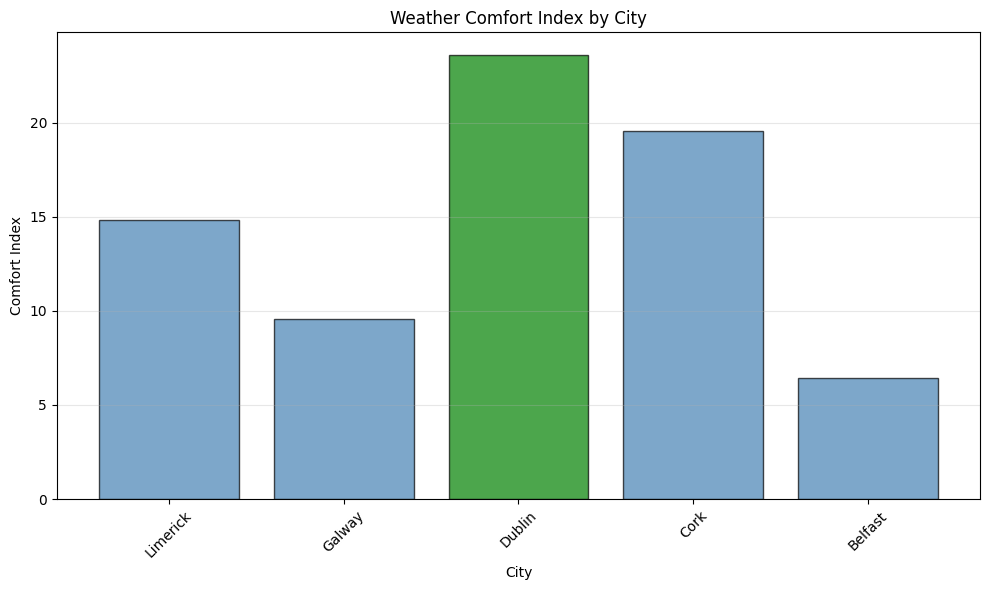

In [55]:
# Calculate comfort index
weather_merged['comfort_index'] = (weather_merged['temperature'] *
                                   (100 - weather_merged['humidity']) /
                                   weather_merged['wind_speed'])

# Find the best city
best_idx = weather_merged['comfort_index'].idxmax()
best_city = weather_merged.loc[best_idx, 'city']
print(f"Highest comfort: {best_city} ({weather_merged.loc[best_idx, 'comfort_index']:.2f})")

# Visualise
plt.figure(figsize=(10, 6))
colors = ['green' if c == best_city else 'steelblue' for c in weather_merged['city']]
plt.bar(weather_merged['city'], weather_merged['comfort_index'], color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('City')
plt.ylabel('Comfort Index')
plt.title('Weather Comfort Index by City')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Challenge 2: Image Processing
Your code here.

In [56]:
# Challenge 2: Image Processing
# Your code here


### Challenge 3: Sklearn Practice
Your code here.

In [57]:
# Challenge 3: Sklearn Practice
# Your code here


---
## Summary — Key Takeaways for the Exam

### Pandas
- `pd.read_csv()` / `pd.read_json()` — load data
- `df.head()`, `df.describe()`, `df.info()` — explore
- `df.fillna()` / `df.dropna()` — handle missing data
- `df.groupby().agg()` — aggregation
- `pd.merge(df1, df2, on='col')` — join tables
- Boolean indexing: `df[df['col'] > value]`
- New columns: `df['new'] = df['a'] + df['b']`

### Matplotlib
- `plt.plot()` — line, `plt.bar()` — bar, `plt.scatter()` — scatter, `plt.hist()` — histogram
- `plt.imshow()` — images
- `plt.subplots(rows, cols)` — multiple plots
- Always call `plt.tight_layout()` and `plt.show()`

### Images
- Images are numpy arrays: shape `(height, width, 3)` for RGB
- Pixel values: 0–255 (uint8), normalise to 0–1 for ML by dividing by 255
- PIL uses RGB, OpenCV uses BGR
- Channel access: `img[:, :, 0]` = red channel

### Scikit-learn Workflow
```python
from sklearn.model_name import ModelClass
model = ModelClass()         # Instantiate
model.fit(X_train, y_train)  # Train
y_pred = model.predict(X_test)  # Predict
score = metric(y_test, y_pred)  # Evaluate
```
- `train_test_split()` to split data
- Regression metrics: MSE, R²
- Classification metrics: accuracy, precision, recall, F1
- `StandardScaler` for feature scaling